In [82]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-210*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

import numpy, torch, scipy
print("NumPy :", numpy.__version__)   # → 1.26.4
print("Torch :", torch.__version__)   # → 2.2.2
print("SciPy :", scipy.__version__)   # → 1.15.2

2024-06-27 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']
NumPy : 2.2.4
Torch : 2.5.1
SciPy : 1.15.2


In [83]:

window_step_length = 5
window_size = 20
num_test_points = 211

horizon = 10 #3 is good
target_idx = 0



In [84]:
import matplotlib.pyplot as plt
import numpy as np
import deeptrack as dt
import torch
from torch.utils.data import DataLoader
def generate_loaders_and_benchmark_new_norm(raw_numpy_data, window_step_length, num_test_points, window_size, horizon, target_idx, minimal_plotting=False):

    data = raw_numpy_data[:-num_test_points]
    test_real_data = raw_numpy_data[-num_test_points:]
    #print(data[-1])
    #print(test_real_data[0])
    if not minimal_plotting:
        plt.plot(test_real_data[:,0])
        plt.title('Test data plot')
        plt.show()

    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    in_sequences, targets = [], []
    for i in range(past_seq, n_samples - lag, window_step_length):
        in_sequences.append(data[i - past_seq:i, :])
        targets.append(data[i + lag:i + lag + 1, target_idx])
    in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)
    #print(in_sequences[10][horizon,target_idx])
    #print(targets[9])

    print('in sequences shape: ',in_sequences.shape)
    print('targets shape: ',targets.shape)
    eps = 0
    mean_win = in_sequences.mean(axis=0, keepdims=True)
    std_win = in_sequences.std(axis=0, keepdims=True) + eps

    print(in_sequences[0,0])
    print(mean_win[0,0])
    print(std_win[0,0])
    in_sequences_norm = (in_sequences - mean_win) / std_win
    print(in_sequences_norm[0,0])
    target_mean = mean_win[:,0,target_idx]
    target_std = std_win[:,0,target_idx]
    targets_norm = ((targets.squeeze(-1) - target_mean) / target_std)
    targets_norm = targets_norm.reshape(-1,1)
    print('in sequences norm shape: ',in_sequences_norm.shape)
    print('targets norm shape: ',targets_norm.shape)

    sources = dt.sources.Source(inputs=in_sequences_norm, targets=targets_norm)
    train_sources, val_sources = dt.sources.random_split(sources, [0.8, 0.2])

    inputs_pipeline = dt.Value(sources.inputs) >> dt.pytorch.ToTensor(dtype=torch.float)
    targets_pipeline = dt.Value(sources.targets) >> dt.pytorch.ToTensor(dtype=torch.float) 

    train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                       inputs=train_sources)
    val_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                     inputs=val_sources)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    print('train loader length: ', len(train_loader))
    print('val loader length: ', len(val_loader))
    #for x, y in train_loader:
    #    print(y[0])
    #    print(x[0])
    target_data = data[:, target_idx]
    indices = np.arange(0, len(target_data)-lag)
    diffs = np.abs(target_data[indices + lag] - target_data[indices])
    benchmark_raw = np.mean(diffs)
    benchmark = 0.1 #benchmark_raw / train_std[target_idx]


    print(f"Benchmark Celsius: {benchmark_raw}")
    print(f"Normalized Benchmark: {benchmark}")

    return train_loader, val_loader, benchmark, mean_win, std_win

In [85]:
def generate_weights_from_predictions_new_norm(model, window_size, real_data, target_idx, num_of_future_predictions, horizon, kelly_clip = 1, print_values_for_allocation=False):
    model.eval()

    # 1) Compute in‐sample return variance (on training history)
    #    use price in column 0
    prices = real_data[:-num_of_future_predictions, 0]
    ret = (prices[horizon:] - prices[:-horizon]) / prices[:-horizon]
    sigma2 = np.var(ret)
    print('variance of returns for old data: ', sigma2)


    last_window = torch.tensor(real_data[-window_size-num_of_future_predictions:-num_of_future_predictions], dtype=torch.float32)
    
    print('start window shape: ',last_window.shape)
    #print(last_window)

    test_real_data_torch = torch.tensor(real_data[-num_of_future_predictions:], dtype=torch.float32)

    #train_mean = real_data.mean(axis=0)
    #train_std = real_data.std(axis=0)
    #train_mean_torch = torch.tensor(train_mean, dtype=torch.float32)
    #train_std_torch = torch.tensor(train_std, dtype=torch.float32)
    #print(train_mean_torch)
    #print(train_std_torch)

    #test_real_data_torch_norm = (test_real_data_torch - train_mean_torch)/ train_std_torch
    print('test data shape', test_real_data_torch.shape)

    #print(test_real_data_torch)

    preds_norm = np.zeros(num_of_future_predictions)
    weights = np.zeros(int(num_of_future_predictions/horizon))
    

    with torch.no_grad():
        for t in range(int(num_of_future_predictions/horizon)-1):

            idx_start = t * horizon
            idx_end = idx_start + horizon
            lw_mean = last_window.mean(axis=0, keepdim=True)
            lw_std = last_window.std(axis=0, keepdim=True)
            #lw_mean_t = torch.tensor(lw_mean)
            #lw_std_t = torch.tensor(lw_std)
            print('lw mean', lw_mean)

            last_window_norm = (last_window - lw_mean ) / lw_std

            x_in  = last_window_norm.unsqueeze(0)
            pred_torch = model(x_in)
            #print('pred:', pred_torch)
            pred_norm = pred_torch.squeeze().item()

            preds_norm[idx_start] = pred_norm
            #print('real: ', test_real_data_torch[t, 0])

            last_price_real = test_real_data_torch[idx_start, 0] if t>0 else real_data[-num_of_future_predictions-1, 0]
            #print(last_price_real)
            pred_price = pred_norm * lw_std[0,target_idx] + lw_mean[0,target_idx]
            pred_ret = (pred_price - last_price_real)/last_price_real
            print('ret shape', pred_ret.shape)

            #kelly weight
            k = pred_ret / np.sqrt(sigma2) if sigma2 > 1e-8 else 0.0
            k = np.clip(k, -kelly_clip, kelly_clip)
            #print(k.shape)

            weights[t] = k
            
            true_horizon_price = test_real_data_torch[idx_end, 0]
            if print_values_for_allocation:
                print('x_in shape: ', x_in.shape)
                print('windows last price: ',x_in[0,-1,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last2 price: ',x_in[0,-2,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])
                print('windows last3 price: ',x_in[0,-3,0] * lw_std[0,target_idx] + lw_mean[0,target_idx])

                print(f'period from idx: ', idx_start, ' to idx ', idx_end)
                
                print(f'prediction at {horizon}: ', pred_price)
                print('last price from test data: ', last_price_real)
                print(f'real price {horizon} steps forward: ', true_horizon_price)
                print(f'kelly weight: ', {k})
                print(' ')
            
            

            true_row = test_real_data_torch[idx_end, :]# if t>0 else real_data[-num_of_future_predictions-1, 0]
            #true_indicators[0] = pred_norm

            next_data_point = torch.tensor(true_row, dtype=torch.float32)
            if horizon > 1:
                middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)
                #print(middle_points.shape)
                #print(next_data_point.unsqueeze(0).shape)
                #print('last window in: ',last_window.shape)
                modified_next_data_point = torch.cat([middle_points, next_data_point.unsqueeze(0)], dim=0)
            else:
                modified_next_data_point = next_data_point.unsqueeze(0)
            #print('mod shape', modified_next_data_point.shape)
            last_window = torch.cat([last_window[horizon:], modified_next_data_point], dim=0)
            #print('last window shape: ', last_window.shape)

    return preds_norm, weights

In [86]:
def generate_test_data_loader(data):
    in_seqs, targets, mu_list, sigma_list = [], [], [], []
    n_samples = data.shape[0]
    past_seq = window_size
    lag = horizon

    for i in range(past_seq, n_samples - lag, window_step_length):
        win   = data[i - past_seq : i, :]           # (past_seq, F)
        μ     = win.mean(axis=0)                    # (F,)
        σ     = win.std(axis=0) + 1e-8              # (F,)
    
        in_seqs.append((win - μ) / σ)               # normalised
        targets.append(data[i + lag, target_idx])   # scalar
        mu_list.append(μ[target_idx])
        sigma_list.append(σ[target_idx])
    
    in_seqs = np.asarray(in_seqs)                   # (N, past_seq, F)
    targets = np.asarray(targets).reshape(-1, 1)    # (N, 1)
    mu_arr  = np.asarray(mu_list).reshape(-1, 1)    # (N, 1)
    sigma_arr = np.asarray(sigma_list).reshape(-1, 1)
    
    targets_norm = (targets - mu_arr) / sigma_arr   # (N, 1)
    
    # ------------------------------------------------------------------
    # Build dt Source with μ and σ columns
    # ------------------------------------------------------------------
    test_sources = dt.sources.Source(
        inputs=in_seqs,
        targets=targets_norm,
        mu=mu_arr,
        sigma=sigma_arr,
    )
    
    
    # ------------------------------------------------------------------
    # Pipelines  →  tensors
    # ------------------------------------------------------------------
    to_tensor = dt.pytorch.ToTensor(dtype=torch.float)
    
    inp_pipe  = dt.Value(test_sources.inputs) >> to_tensor
    tgt_pipe  = dt.Value(test_sources.targets) >> to_tensor
    mu_pipe   = dt.Value(test_sources.mu)      >> to_tensor
    sigma_pipe= dt.Value(test_sources.sigma)   >> to_tensor
    
    dataset_cols = inp_pipe & tgt_pipe & mu_pipe & sigma_pipe
    
    test_ds = dt.pytorch.Dataset(dataset_cols, inputs=test_sources)
    
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

    return test_loader
   

In [87]:
def test_model_output_percentage_diff_new_norm(model, data_loader, tm, tstd, target_idx, num_tests=20):
    
    model.eval()

    all_preds_real, all_true_real = [], []
    first_batch = None   # keep for pretty print

    with torch.no_grad():
        for x_batch, y_norm, mu_batch, sigma_batch in data_loader:
            # to(device) only if you trained on GPU
            #x_batch     = x_batch.to(device)
            #y_norm      = y_norm.to(device)
            #mu_batch    = mu_batch.to(device)
            #sigma_batch = sigma_batch.to(device)

            # forward
            out = model(x_batch)
            if isinstance(out, (tuple, list)):   # ignore extra returns
                out = out[0]
            out = out.squeeze(-1)                # (B,)

            # ------------------------------------------
            # de-normalise: y_real = y_norm * σ + μ
            # ------------------------------------------
            preds_real = out * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)
            true_real  = y_norm.squeeze(-1) * sigma_batch.squeeze(-1) + mu_batch.squeeze(-1)

            all_preds_real.append(preds_real)
            all_true_real.append(true_real)

            if first_batch is None:
                first_batch = (
                    x_batch.cpu(),      # still normalised
                    y_norm.cpu(),
                    mu_batch.cpu(),
                    sigma_batch.cpu(),
                    out.cpu(),          # preds in norm space
                )

    # ------------------------------------------------------------------
    # 1. MAPE over the whole loader   (real price space)
    # ------------------------------------------------------------------
    preds = torch.cat(all_preds_real)            # (N,)
    truth = torch.cat(all_true_real)             # (N,)

    mape = ((preds - truth).abs() / truth.abs().clamp(min=1e-8) * 100).mean().item()
    print(f"\nMean absolute percentage error (MAPE): {mape:.2f}%")

    # ------------------------------------------------------------------
    # 2. Pretty-print a few samples from the first batch
    # ------------------------------------------------------------------
    x_b, y_norm_b, mu_b, sigma_b, p_norm_b = first_batch
    num_tests = min(num_tests, x_b.size(0))

    print(f"\nFirst-batch sample comparisons (n = {num_tests}):")
    for i in range(num_tests):
        # last raw price of target feature in the window
        last_price = (
            x_b[i, -1, target_idx].item() * sigma_b[i].item() + mu_b[i].item()
        )

        true_price = y_norm_b[i].item() * sigma_b[i].item() + mu_b[i].item()
        pred_price = p_norm_b[i].item()  * sigma_b[i].item() + mu_b[i].item()
        pct = abs(pred_price - true_price) / abs(true_price) * 100

        print(
            f"  Sample {i+1:2d}: "
            f"Last input price = {last_price:9.4f}, "
            f"True = {true_price:9.4f}, "
            f"Pred = {pred_price:9.4f}, "
            f"Pct diff = {pct:6.2f}%"
        )

    return mape

Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


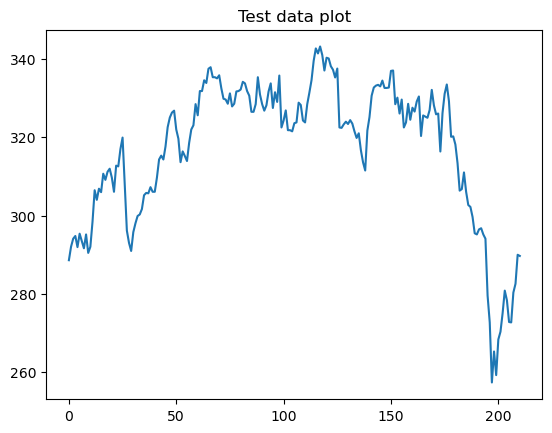

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[2.68834782e+01 1.57131000e+05 2.83150229e+10 1.55002267e-02
 3.92147114e-03 3.91380222e-03 6.07836916e-05 2.63111549e+01
 2.67990432e+01 5.31894275e+01 2.79775678e-02]
[ 9.61238407e+01  4.02459161e+06  1.01242434e+11  3.33311481e-02
  1.17113338e-04 -8.25124664e-05  1.71957209e-05  9.57204672e+01
  9.57153637e+01  5.22933968e+01  1.83676766e-02]
[7.98189543e+01 4.52537688e+06 8.40693124e+10 1.28691708e-02
 1.99798164e-02 1.99865145e-02 6.30204570e-04 7.93948540e+01
 7.93632003e+01 1.04966553e+01 8.93720631e-03]
[-0.86746767 -0.85461625 -0.86746767 -1.38555324  0.19041005  0.19995056
  0.0691648  -0.87422936 -0.8683662   0.08536346  1.07526791]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 3.408219768373752
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

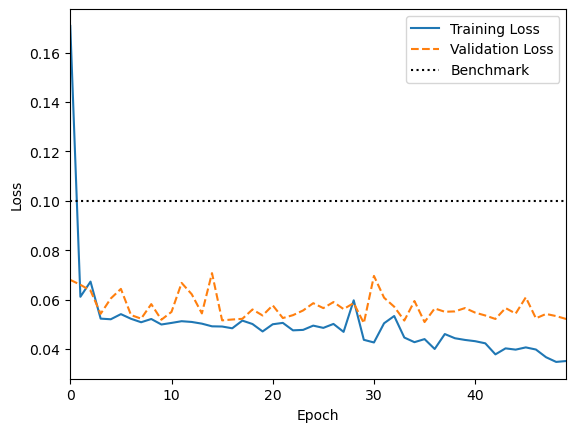

variance of returns for old data:  0.0029584015398135912
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 2.9964e+02,  1.5246e+06,  3.1560e+11,  4.2355e-02, -3.0314e-03,
         -3.0941e-03, -1.2699e-04,  3.0315e+02,  3.0207e+02,  4.7307e+01,
          1.0340e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(289.1033)
windows last2 price:  tensor(291.7538)
windows last3 price:  tensor(291.8520)
period from idx:  0  to idx  10
prediction at 10:  tensor(299.9963)
last price from test data:  289.103271484375
real price 10 steps forward:  tensor(292.0483)
kelly weight:  {tensor(0.6927)}
 
lw mean tensor([[ 2.9510e+02,  1.7884e+06,  3.1081e+11,  4.2072e-02, -1.7097e-03,
         -1.7790e-03, -7.0629e-05,  2.9952e+02,  2.9846e+02,  4.4426e+01,
          1.0898e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(292.0483)
windows last2 price:  tensor(29

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


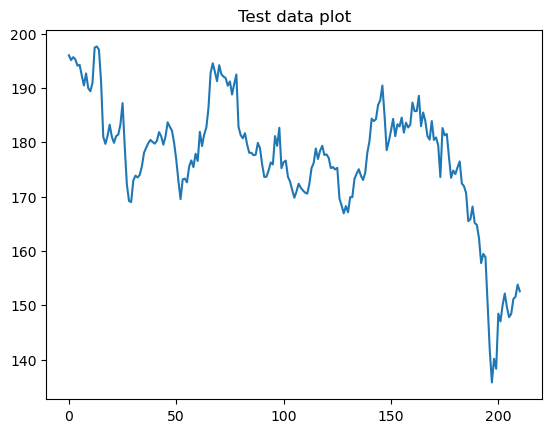

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 3.57618880e+00  3.04256470e+07  1.18267779e+10  6.47422180e-03
 -4.30106086e-02 -4.39629729e-02 -2.78460220e-04  3.98403440e+00
  3.95145295e+00  2.49887626e+01  2.47445707e-02]
[3.83295540e+01 3.78259447e+07 1.26759282e+11 3.66688707e-02
 6.14076038e-04 3.90046967e-04 5.43347493e-05 3.80497536e+01
 3.80495391e+01 5.31308794e+01 1.95272207e-02]
[4.30192451e+01 5.89376063e+07 1.42268512e+11 2.14987533e-02
 2.11378900e-02 2.11796310e-02 7.80927014e-04 4.25904308e+01
 4.25801462e+01 1.12200106e+01 8.81391491e-03]
[-0.80785623 -0.12556156 -0.80785623 -1.40448372 -2.06381454 -2.09413563
 -0.42615374 -0.79984444 -0.80079777 -2.50820768  0.59194468]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.5719702988959314
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

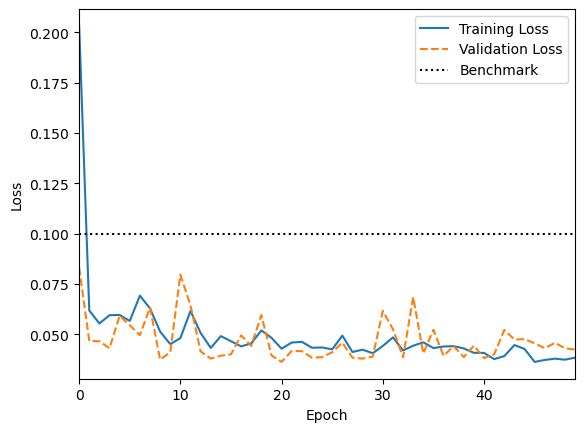

variance of returns for old data:  0.003518807155455724
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.9767e+02,  3.8128e+06,  6.5370e+11,  8.7733e-02, -1.6393e-03,
         -1.7078e-03, -1.4143e-04,  1.9745e+02,  1.9638e+02,  5.5598e+01,
          1.0480e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(193.6487)
windows last2 price:  tensor(198.7073)
windows last3 price:  tensor(194.8275)
period from idx:  0  to idx  10
prediction at 10:  tensor(197.7209)
last price from test data:  193.64874267578125
real price 10 steps forward:  tensor(189.3760)
kelly weight:  {tensor(0.3545)}
 
lw mean tensor([[ 1.9515e+02,  3.3023e+06,  6.4538e+11,  8.7358e-02, -3.2886e-03,
         -3.3547e-03, -2.8368e-04,  1.9735e+02,  1.9642e+02,  4.8590e+01,
          1.1146e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(189.3760)
windows last2 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


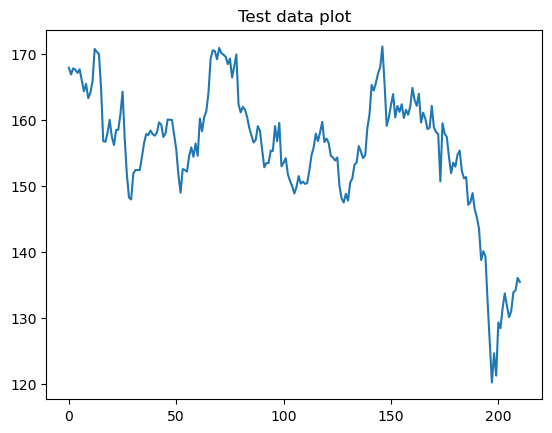

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.76596975e+00  8.51722400e+06  4.31734687e+09  2.36340459e-03
 -5.89518352e-02 -6.07609561e-02 -1.39327038e-04  3.11219729e+00
  3.08784515e+00  2.64108343e+01  2.97870997e-02]
[3.31729343e+01 6.02776803e+06 5.17789697e+10 1.48476714e-02
 5.56439412e-04 3.13649414e-04 2.17371255e-05 3.29286675e+01
 3.29282463e+01 5.30576098e+01 2.02964203e-02]
[3.74417647e+01 5.38616637e+06 5.84421017e+10 8.95794100e-03
 2.20216972e-02 2.20424667e-02 3.27668710e-04 3.70730572e+01
 3.70639044e+01 1.07882651e+01 9.11579617e-03]
[-0.81211355  0.46219441 -0.81211355 -1.39365361 -2.70225651 -2.77077001
 -0.49154575 -0.80426251 -0.80510679 -2.46997781  1.04112457]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.370557661355505
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

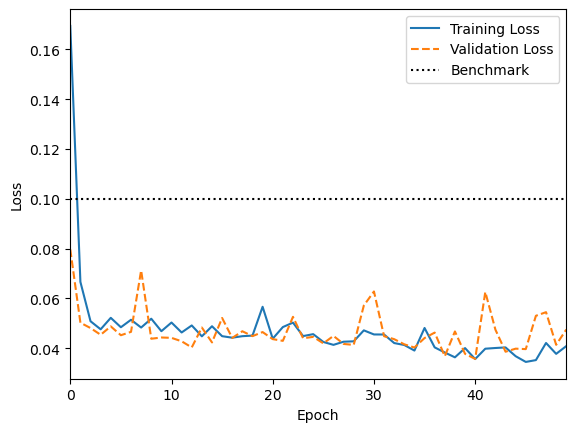

variance of returns for old data:  0.0036949151665209012
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.6976e+02,  1.7292e+06,  2.6498e+11,  3.5562e-02, -1.8395e-03,
         -1.9275e-03, -6.4052e-05,  1.6993e+02,  1.6901e+02,  5.4013e+01,
          1.2288e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(165.8531)
windows last2 price:  tensor(170.2151)
windows last3 price:  tensor(166.3433)
period from idx:  0  to idx  10
prediction at 10:  tensor(169.8083)
last price from test data:  165.85313415527344
real price 10 steps forward:  tensor(164.0397)
kelly weight:  {tensor(0.3923)}
 
lw mean tensor([[ 1.6768e+02,  1.3174e+06,  2.6173e+11,  3.5428e-02, -2.8765e-03,
         -2.9512e-03, -1.0048e-04,  1.6959e+02,  1.6881e+02,  4.8343e+01,
          1.2568e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(164.0397)
windows last2 price:  tensor(

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


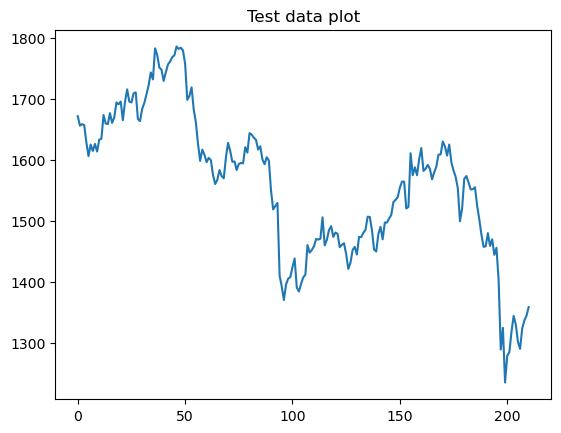

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.70022095e+02  1.27078000e+06  4.18588269e+11  2.29143839e-01
 -6.10652330e-03 -6.12524436e-03 -1.39927219e-03  2.79458354e+02
  2.78083609e+02  3.75416964e+01  1.74502300e-02]
[ 5.22977018e+02  1.01844533e+06  8.10719006e+11  3.15752118e-01
  1.70460082e-05 -1.29996571e-04 -2.32122702e-05  5.21118386e+02
  5.21161481e+02  5.17097966e+01  1.46495583e-02]
[3.45179538e+02 9.19956039e+05 5.35097342e+11 6.97778488e-02
 1.70648586e-02 1.71968263e-02 6.11568511e-03 3.42598158e+02
 3.42551799e+02 1.23470986e+01 6.51607531e-03]
[-0.73282132  0.27428992 -0.73282132 -1.2412002  -0.3588409  -0.34862524
 -0.22500503 -0.70537458 -0.70960909 -1.14748417  0.4298096 ]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 18.728531857806786
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

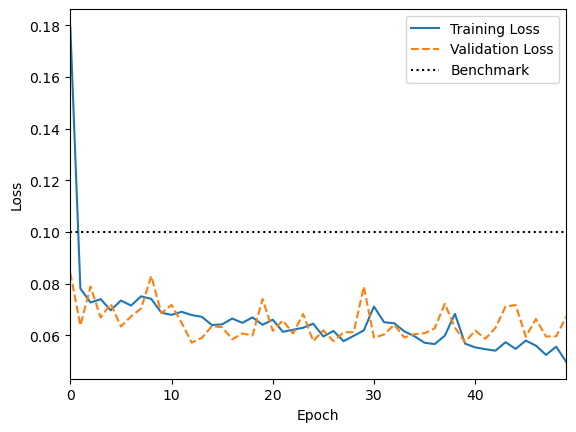

variance of returns for old data:  0.002304140837237494
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[1.6530e+03, 2.3381e+05, 2.5625e+12, 3.4393e-01, 1.4992e-04, 1.0452e-04,
         6.5017e-05, 1.6558e+03, 1.6454e+03, 5.5506e+01, 1.0930e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(1673.4552)
windows last2 price:  tensor(1659.4764)
windows last3 price:  tensor(1641.5038)
period from idx:  0  to idx  10
prediction at 10:  tensor(1652.0214)
last price from test data:  1673.4552001953125
real price 10 steps forward:  tensor(1633.0167)
kelly weight:  {tensor(-0.2668)}
 
lw mean tensor([[ 1.6433e+03,  1.8502e+05,  2.5474e+12,  3.4484e-01, -1.5184e-03,
         -1.5645e-03, -5.1615e-04,  1.6547e+03,  1.6496e+03,  4.9960e+01,
          9.7663e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(1633.0167)
windows last2 price:  tensor(1613.5463)
win

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


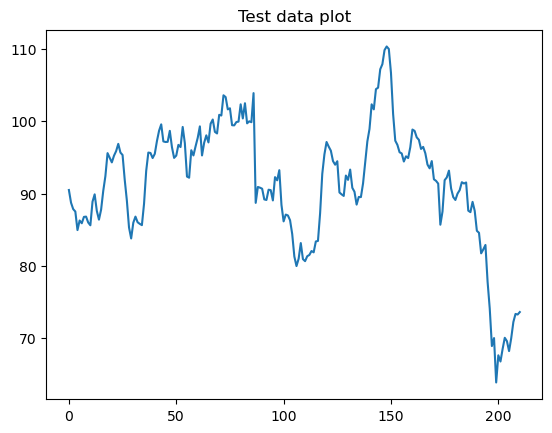

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.73251572e+01  1.65003200e+06  7.16752513e+09  3.92365086e-03
 -5.06330515e-02 -5.19598865e-02 -1.98666416e-04  3.01378270e+01
  2.98728204e+01  2.75933695e+01  2.55974566e-02]
[8.53439552e+01 2.53751123e+06 2.23861455e+10 8.62259592e-03
 8.33306751e-04 6.13413294e-04 7.27661775e-06 8.52459160e+01
 8.52452245e+01 5.09879065e+01 2.06584736e-02]
[5.17664484e+01 1.76779387e+06 1.35785978e+10 2.72658541e-03
 2.10453273e-02 2.09226650e-02 1.82184007e-04 5.17127469e+01
 5.16502173e+01 1.20623672e+01 9.20085249e-03]
[-1.12077996 -0.50202642 -1.12077996 -1.72338084 -2.44550049 -2.51274395
 -1.13041225 -1.06565774 -1.07206527 -1.93946484  0.53679624]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 3.971982185657208
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

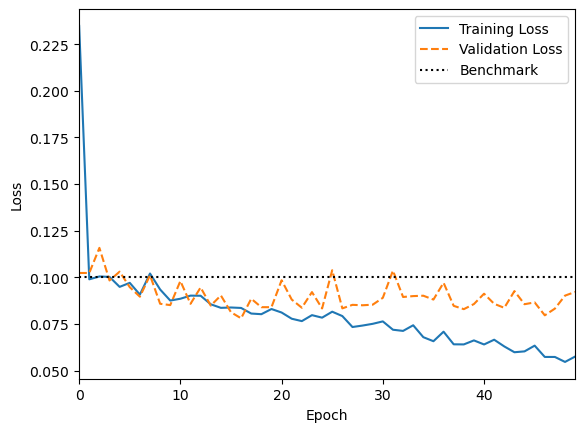

variance of returns for old data:  0.004428616711752939
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 9.5715e+01,  1.5489e+06,  2.5107e+10,  3.3693e-03, -4.0369e-03,
         -4.3658e-03, -1.2032e-05,  9.8047e+01,  9.7211e+01,  4.7290e+01,
          2.3368e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(87.4600)
windows last2 price:  tensor(92.9800)
windows last3 price:  tensor(92.2800)
period from idx:  0  to idx  10
prediction at 10:  tensor(95.6268)
last price from test data:  87.45999908447266
real price 10 steps forward:  tensor(85.6200)
kelly weight:  {tensor(1.4032)}
 
lw mean tensor([[ 9.0109e+01,  1.4938e+06,  2.3636e+10,  3.1989e-03, -6.3517e-03,
         -6.5895e-03, -1.9550e-05,  9.4747e+01,  9.3910e+01,  4.0945e+01,
          2.2493e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(85.6200)
windows last2 price:  tensor(86.)
win

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


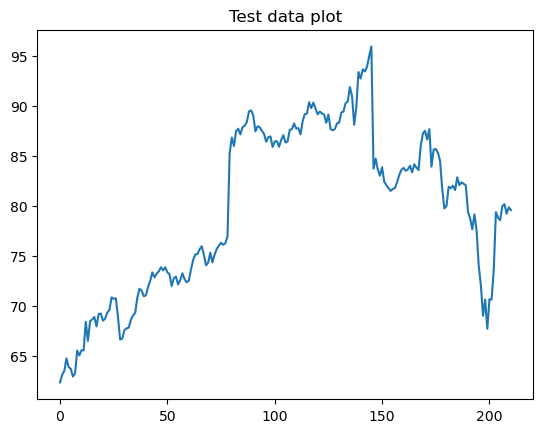

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 3.12475800e+02  5.59376930e+07  9.59588162e+11  5.25298322e-01
 -9.53905175e-03 -9.58483992e-03 -5.01084788e-03  2.81729825e+02
  2.87650963e+02  6.76608207e+01  3.46125789e-02]
[ 7.18647533e+01  1.61377505e+07  2.20690904e+11  1.07471983e-01
 -7.87096687e-04 -1.19949847e-03 -1.28549036e-05  7.22154822e+01
  7.22167642e+01  5.03054151e+01  2.32345816e-02]
[6.10504377e+01 1.48749653e+07 1.87481006e+11 9.80548632e-02
 2.82453674e-02 2.89618507e-02 4.78737152e-03 6.11513957e+01
 6.10514724e+01 1.21469708e+01 1.39143839e-02]
[ 3.94118462  2.67563263  3.94118462  4.26114855 -0.30985453 -0.28953058
 -1.04399522  3.42615798  3.5287306   1.42878466  0.81771477]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 4.3358962229165865
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

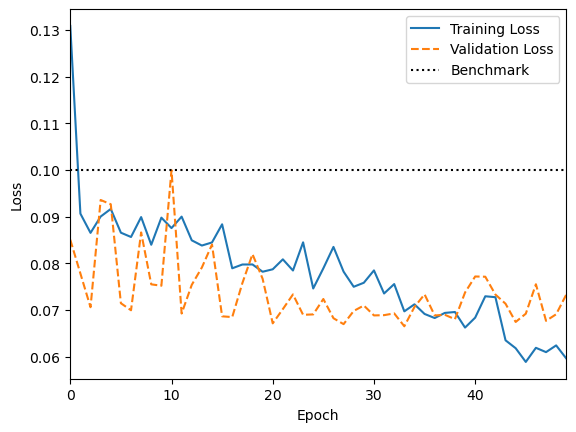

variance of returns for old data:  0.0070732489417747865
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[6.1695e+01, 7.9581e+06, 1.8946e+11, 2.5426e-02, 8.1177e-04, 7.1989e-04,
         2.2989e-05, 6.0499e+01, 6.0344e+01, 6.2549e+01, 1.4995e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(62.1467)
windows last2 price:  tensor(62.7068)
windows last3 price:  tensor(60.8335)
period from idx:  0  to idx  10
prediction at 10:  tensor(61.6286)
last price from test data:  62.14674377441406
real price 10 steps forward:  tensor(65.6036)
kelly weight:  {tensor(-0.0991)}
 
lw mean tensor([[6.2541e+01, 6.9005e+06, 1.9206e+11, 2.6003e-02, 2.0530e-03, 1.9336e-03,
         5.7985e-05, 6.1888e+01, 6.1593e+01, 5.8287e+01, 1.3955e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(65.6036)
windows last2 price:  tensor(65.0822)
windows last3 price:  tensor(65.5650)

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


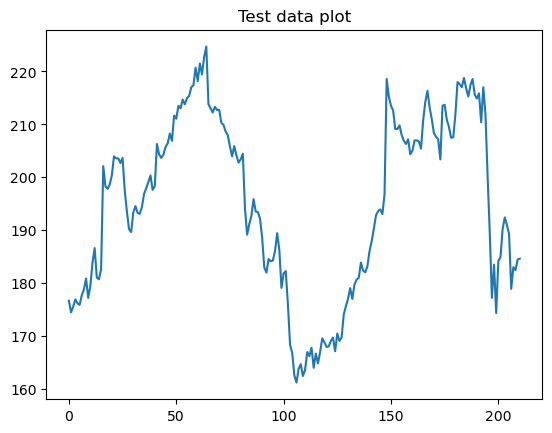

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 9.10091019e+00  2.01714500e+06  2.31301453e+09  1.26619179e-03
 -9.99990767e-03 -1.00502426e-02 -1.26618009e-05  9.08712144e+00
  9.10202532e+00  5.18001043e+01  1.60951852e-02]
[9.88205259e+01 1.04700835e+06 2.51154343e+10 9.34307933e-03
 7.44965525e-04 5.28970358e-04 7.11152948e-06 9.84453449e+01
 9.84554322e+01 5.26218431e+01 1.84889008e-02]
[7.40863117e+01 9.11618336e+05 1.88291843e+10 3.60053537e-03
 2.07317648e-02 2.08086733e-02 1.92025592e-04 7.36754182e+01
 7.36274456e+01 1.20020845e+01 7.79511156e-03]
[-1.21101474  1.06419168 -1.21101474 -2.24324627 -0.51828068 -0.50840401
 -0.10297237 -1.21286347 -1.21358831 -0.06846634 -0.30707907]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 4.7047041485828975
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

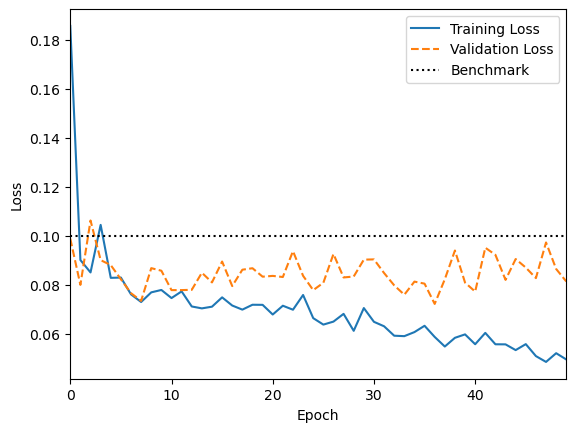

variance of returns for old data:  0.0037350937914727767
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.7961e+02,  8.1233e+05,  4.5648e+10,  6.1262e-03, -2.7293e-03,
         -2.8133e-03, -1.6509e-05,  1.8846e+02,  1.8825e+02,  3.5248e+01,
          2.5188e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(176.0240)
windows last2 price:  tensor(175.7802)
windows last3 price:  tensor(173.6354)
period from idx:  0  to idx  10
prediction at 10:  tensor(179.4860)
last price from test data:  176.02395629882812
real price 10 steps forward:  tensor(179.4850)
kelly weight:  {tensor(0.3218)}
 
lw mean tensor([[1.7663e+02, 6.8970e+05, 4.4890e+10, 6.0770e-03, 1.1848e-04, 5.1711e-05,
         1.0175e-06, 1.7942e+02, 1.8121e+02, 3.9043e+01, 1.4292e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(179.4850)
windows last2 price:  tensor(177.1939)
windows la

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


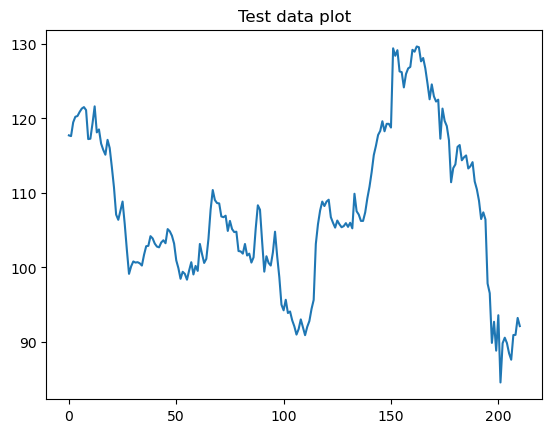

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 1.14148211e+00  9.72000000e+05  2.93832326e+09  1.60849867e-03
 -8.00099289e-03 -8.03317259e-03 -1.28695864e-05  1.18267759e+00
  1.18423892e+00  3.25515117e+01  1.63444294e-02]
[ 3.72556513e+01  5.08410013e+06  9.59008866e+10  2.75130859e-02
 -2.09110848e-04 -4.50116499e-04  1.09824203e-05  3.70807375e+01
  3.70781065e+01  5.35748647e+01  1.97786328e-02]
[4.00247778e+01 6.60007428e+06 1.03028978e+11 1.80704173e-02
 2.18861441e-02 2.19900428e-02 6.13888415e-04 3.98642516e+01
 3.98440719e+01 1.21703410e+01 9.86964680e-03]
[-0.90229531 -0.62303846 -0.90229531 -1.43353564 -0.35601895 -0.34484044
 -0.03885398 -0.90050756 -0.90085842 -1.72742513 -0.34795606]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.596795893709507
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

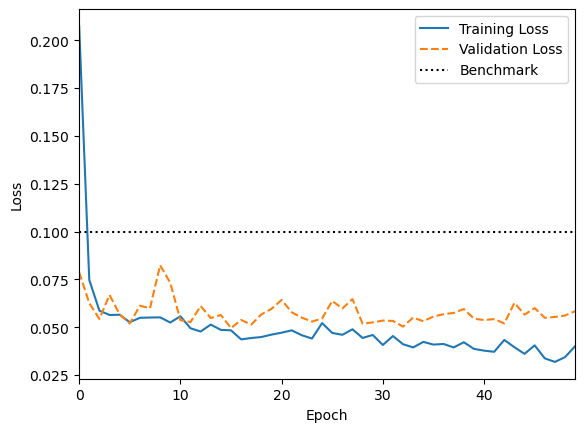

variance of returns for old data:  0.004413972914781559
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.1695e+02,  3.2582e+06,  3.0104e+11,  4.0404e-02, -3.9270e-04,
         -4.9114e-04, -1.3790e-05,  1.1826e+02,  1.1820e+02,  4.4874e+01,
          1.3627e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(116.3266)
windows last2 price:  tensor(117.9742)
windows last3 price:  tensor(118.2238)
period from idx:  0  to idx  10
prediction at 10:  tensor(116.8922)
last price from test data:  116.32659912109376
real price 10 steps forward:  tensor(117.2752)
kelly weight:  {tensor(0.0732)}
 
lw mean tensor([[ 1.1846e+02,  2.7749e+06,  3.0492e+11,  4.1280e-02, -2.4206e-04,
         -3.4120e-04, -7.9069e-06,  1.1762e+02,  1.1802e+02,  5.1017e+01,
          1.3874e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(117.2752)
windows last2 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


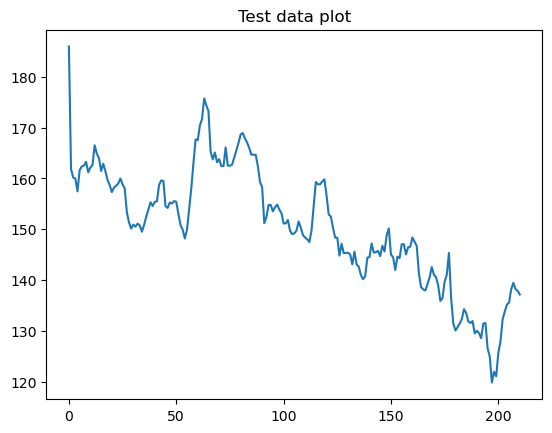

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 5.56863670e+01  9.39295200e+06  7.85227884e+10  4.29849915e-02
 -5.26313638e-02 -5.40669941e-02 -2.26235872e-03  6.30287111e+01
  6.31253374e+01  3.22534727e+01  3.88828957e-02]
[1.10837502e+02 4.39607049e+06 1.56290852e+11 6.80804973e-02
 3.55216897e-04 1.64022862e-04 2.34634036e-05 1.10697018e+02
 1.10698475e+02 5.13472999e+01 1.79913418e-02]
[5.14727455e+01 2.97081941e+06 7.25812028e+10 2.86734933e-02
 1.96387550e-02 1.95174476e-02 1.27324752e-03 5.13558531e+01
 5.12922620e+01 1.18816607e+01 9.30229355e-03]
[-1.07146286  1.68198763 -1.07146286 -0.8752162  -2.6980621  -2.77859166
 -1.79526925 -0.92819618 -0.92749152 -1.60699987  2.24584977]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 4.555541989105166
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

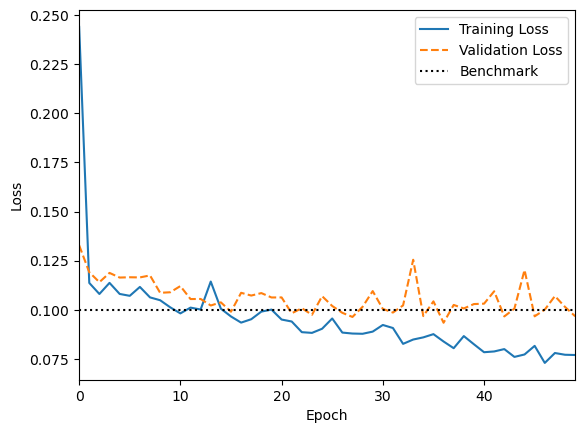

variance of returns for old data:  0.0035474051544911807
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[1.7883e+02, 2.4164e+06, 2.5217e+11, 3.3848e-02, 9.8149e-04, 8.9974e-04,
         3.5835e-05, 1.7471e+02, 1.7449e+02, 6.2611e+01, 1.3861e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(182.1551)
windows last2 price:  tensor(184.4004)
windows last3 price:  tensor(185.5469)
period from idx:  0  to idx  10
prediction at 10:  tensor(178.8817)
last price from test data:  182.15513610839844
real price 10 steps forward:  tensor(162.1386)
kelly weight:  {tensor(-0.3017)}
 
lw mean tensor([[ 1.7098e+02,  3.3888e+06,  2.4110e+11,  3.2631e-02, -4.6662e-03,
         -5.2055e-03, -1.3649e-04,  1.7615e+02,  1.7421e+02,  4.9308e+01,
          2.2959e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(162.1386)
windows last2 price:  tensor(161.2309)
windows l

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


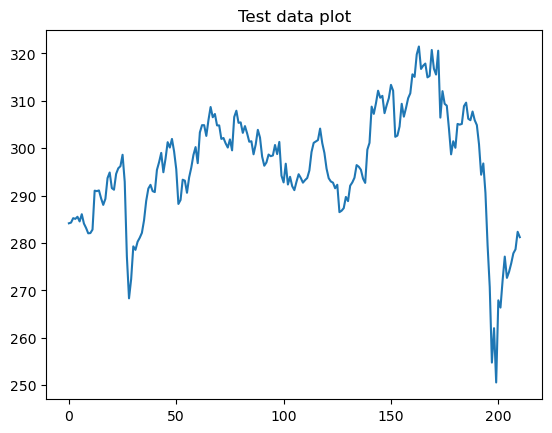

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 1.42888927e+01  4.22727600e+06  2.59524865e+10  1.42069256e-02
 -3.51560694e-02 -3.57889207e-02 -4.99459662e-04  1.45781390e+01
  1.45444687e+01  4.68376428e+01  2.29861783e-02]
[5.96776802e+01 5.94481627e+06 1.08390777e+11 3.31218856e-02
 4.32049329e-04 2.98263748e-04 2.32868138e-05 5.92988190e+01
 5.92986791e+01 5.36949861e+01 1.46769033e-02]
[6.11678638e+01 3.95902783e+06 1.11097353e+11 1.45174157e-02
 1.63318401e-02 1.63672511e-02 5.38305865e-04 6.06034460e+01
 6.05910726e+01 1.19571355e+01 7.02236825e-03]
[-0.7420365  -0.43382879 -0.7420365  -1.30291509 -2.17906363 -2.20484089
 -0.97109563 -0.73792306 -0.73862714 -0.57349382  1.18325823]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 2.001438201282898
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

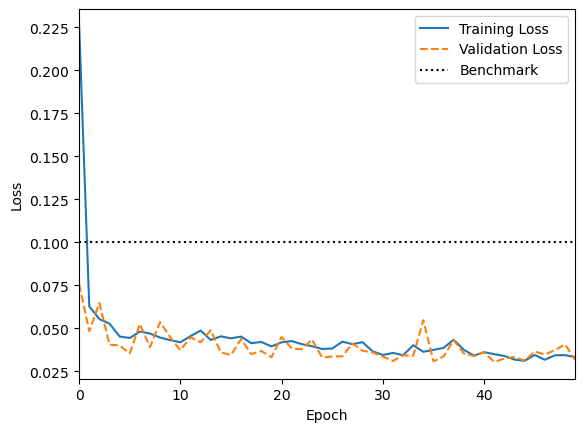

variance of returns for old data:  0.0022920694671373833
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[2.8091e+02, 2.9346e+06, 5.1020e+11, 6.8477e-02, 3.9701e-04, 3.4983e-04,
         2.8656e-05, 2.7843e+02, 2.7748e+02, 6.0727e+01, 9.4942e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(281.9513)
windows last2 price:  tensor(283.9171)
windows last3 price:  tensor(283.0325)
period from idx:  0  to idx  10
prediction at 10:  tensor(280.9678)
last price from test data:  281.9512939453125
real price 10 steps forward:  tensor(282.0987)
kelly weight:  {tensor(-0.0729)}
 
lw mean tensor([[ 2.8292e+02,  2.2188e+06,  5.1386e+11,  6.9564e-02, -3.2428e-04,
         -3.6452e-04, -2.1323e-05,  2.8142e+02,  2.8077e+02,  5.7183e+01,
          9.8556e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(282.0987)
windows last2 price:  tensor(282.0496)
windows la

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


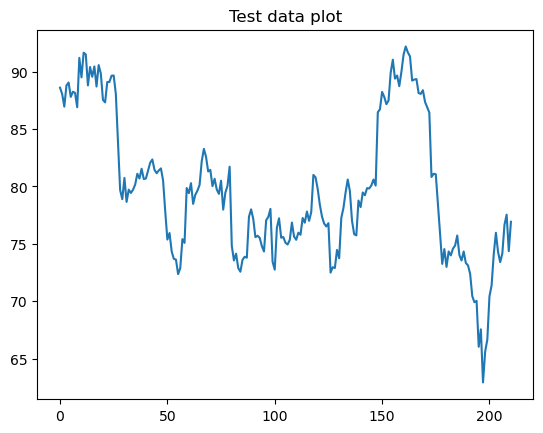

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

[ 2.43462448e+01  2.27230000e+04  5.92142043e+09  3.24150749e-03
 -4.50000037e-02 -4.60439424e-02 -1.45867849e-04  2.38618716e+01
  2.42698545e+01  5.09900698e+01  4.06852812e-02]
[ 8.02215790e+01  1.04707576e+06  1.95112511e+10  6.42432489e-03
  2.12788877e-06 -2.79656299e-04  2.37731961e-06  8.00644623e+01
  8.00653021e+01  5.23032258e+01  2.03938999e-02]
[7.33091824e+01 8.30064066e+05 1.78300388e+10 3.06782834e-03
 2.36923444e-02 2.37753328e-02 1.51887790e-04 7.30746776e+01
 7.30159639e+01 1.31419710e+01 1.08272833e-02]
[-0.76218739 -1.23406469 -0.76218739 -1.03748223 -1.89943768 -1.92486416
 -0.97601768 -0.76911172 -0.76415409 -0.09992078  1.87409721]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 4.152232747272129
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

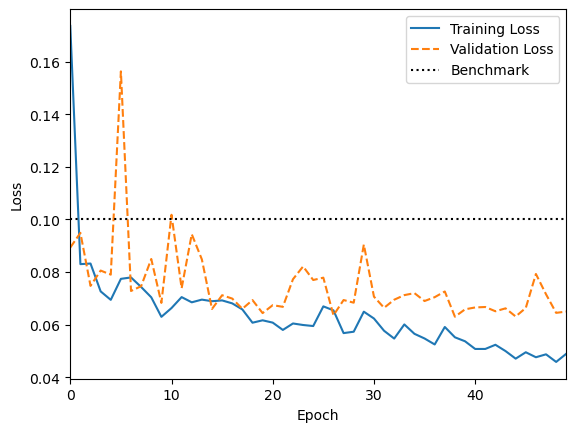

variance of returns for old data:  0.005701771940081212
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.0669e+02,  1.4398e+06,  2.5950e+10,  3.4816e-03, -1.6264e-02,
         -1.7330e-02, -5.2057e-05,  1.1897e+02,  1.1637e+02,  3.7261e+01,
          3.1999e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(88.3500)
windows last2 price:  tensor(92.8000)
windows last3 price:  tensor(91.3000)
period from idx:  0  to idx  10
prediction at 10:  tensor(106.4250)
last price from test data:  88.3499984741211
real price 10 steps forward:  tensor(89.5000)
kelly weight:  {tensor(2.7094)}
 
lw mean tensor([[ 9.1403e+01,  1.4927e+06,  2.2231e+10,  3.0088e-03, -6.3682e-03,
         -6.7662e-03, -1.8845e-05,  1.0518e+02,  1.0318e+02,  2.9610e+01,
          3.9180e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(89.5000)
windows last2 price:  tensor(91.2000)

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


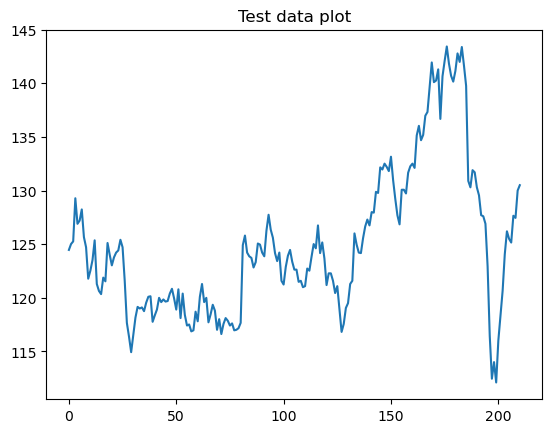

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.91987610e+01  5.18249200e+06  1.01166118e+11  5.53804164e-02
 -4.06524032e-03 -4.07352587e-03 -2.25134701e-04  2.88382475e+01
  2.90680731e+01  5.10001816e+01  2.12955097e-02]
[6.69625043e+01 9.46146963e+06 2.32007673e+11 1.01075522e-01
 3.65860444e-04 1.56020312e-04 4.75088237e-05 6.68108592e+01
 6.68115917e+01 5.21015589e+01 1.74907878e-02]
[2.53494909e+01 6.61131787e+06 8.78293975e+10 2.86678635e-02
 2.04879984e-02 2.04888229e-02 2.19340763e-03 2.51876584e+01
 2.51581552e+01 1.13364934e+01 9.56582409e-03]
[-1.48972393 -0.64722007 -1.48972393 -1.59394875 -0.21627788 -0.20643188
 -0.12430135 -1.50758801 -1.50024985 -0.09715325  0.39774115]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 2.5399934596682487
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

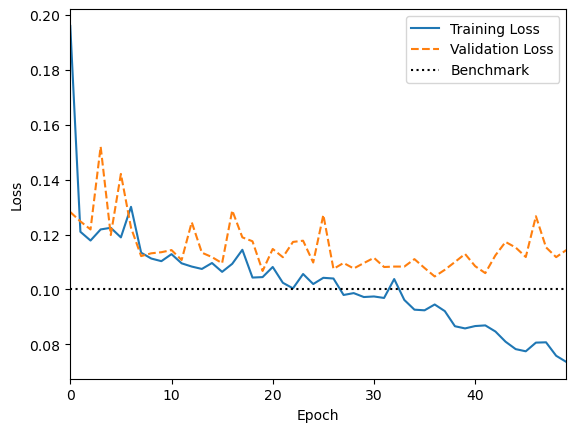

variance of returns for old data:  0.0031876660597336018
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.2736e+02,  3.2875e+06,  4.4127e+11,  5.9226e-02, -1.3002e-03,
         -1.3646e-03, -7.5383e-05,  1.2898e+02,  1.2832e+02,  4.7156e+01,
          1.0490e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(125.6549)
windows last2 price:  tensor(127.0455)
windows last3 price:  tensor(126.4495)
period from idx:  0  to idx  10
prediction at 10:  tensor(127.3078)
last price from test data:  125.65486907958984
real price 10 steps forward:  tensor(122.5259)
kelly weight:  {tensor(0.2330)}
 
lw mean tensor([[ 1.2639e+02,  3.4995e+06,  4.3792e+11,  5.9278e-02, -8.5524e-04,
         -9.6180e-04, -4.7420e-05,  1.2747e+02,  1.2729e+02,  4.6937e+01,
          1.2429e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(122.5259)
windows last2 price:  tensor(

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


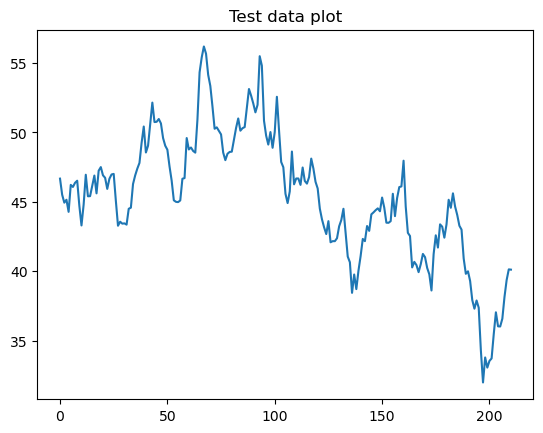

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.87091583e-01  1.26169500e+06  5.11867076e+08  2.80206579e-04
 -9.09040599e-03 -9.13197585e-03 -2.54719156e-06  2.96441962e-01
  2.94675045e-01  3.32485079e+01  1.35629413e-02]
[2.04598938e+01 2.36605889e+06 3.64787638e+10 8.99782241e-03
 1.42972596e-03 1.21284964e-03 1.62604790e-05 2.03580659e+01
 2.03589585e+01 5.41908826e+01 1.88705135e-02]
[3.07170281e+01 3.36148840e+06 5.47666191e+10 8.99413079e-03
 2.08825713e-02 2.07466029e-02 2.88866486e-04 3.06027830e+01
 3.05789387e+01 1.24366441e+01 8.35317564e-03]
[-0.65673027 -0.3285342  -0.65673027 -0.96925607 -0.5037757  -0.49862744
 -0.06510852 -0.65554901 -0.65614715 -1.68392491 -0.63539573]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.1998435797599645
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

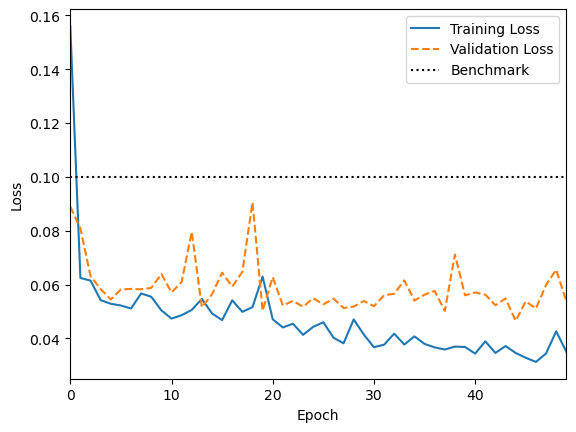

variance of returns for old data:  0.004093979725838302
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 5.0589e+01,  8.1747e+06,  9.0198e+10,  1.2104e-02, -6.2835e-03,
         -6.7006e-03, -7.0266e-05,  5.3457e+01,  5.2601e+01,  4.3911e+01,
          3.7799e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(46.7200)
windows last2 price:  tensor(48.1600)
windows last3 price:  tensor(48.7400)
period from idx:  0  to idx  10
prediction at 10:  tensor(50.4174)
last price from test data:  46.720001220703125
real price 10 steps forward:  tensor(43.3000)
kelly weight:  {tensor(1.2369)}
 
lw mean tensor([[ 4.6797e+01,  6.7948e+06,  8.3437e+10,  1.1293e-02, -6.5958e-03,
         -6.8994e-03, -7.0792e-05,  5.0132e+01,  4.9622e+01,  3.8581e+01,
          2.9065e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(43.3000)
windows last2 price:  tensor(44.7200

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


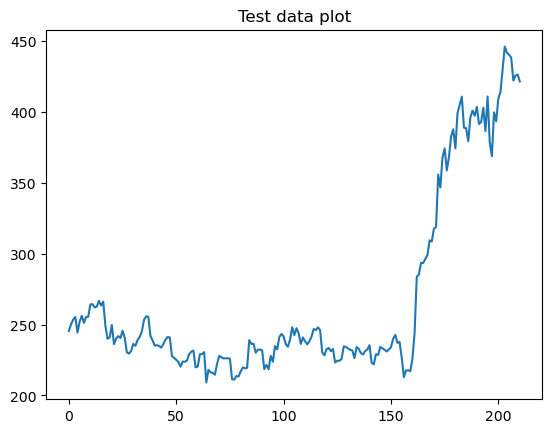

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 8.85961723e+00  5.97897000e+05  4.66473023e+09  2.55356939e-03
 -1.44929227e-02 -1.45989710e-02 -3.70086839e-05  9.26677098e+00
  9.23806656e+00  2.49055810e+01  1.22769308e-02]
[ 4.38383588e+01  9.45809100e+05  2.30815973e+10  8.20850562e-03
 -2.20841264e-04 -4.32388826e-04 -1.71362057e-07  4.35164867e+01
  4.35153907e+01  5.25347777e+01  1.80264665e-02]
[3.73989339e+01 9.43837863e+05 1.96911371e+10 2.75112686e-03
 2.04940148e-02 2.06090712e-02 1.63061477e-04 3.66551219e+01
 3.66118774e+01 1.25987040e+01 8.96228271e-03]
[-0.93528713 -0.36861427 -0.93528713 -2.05549817 -0.69640242 -0.68739547
 -0.22591064 -0.93437735 -0.93623509 -2.19301895 -0.64152582]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 2.092147050708359
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

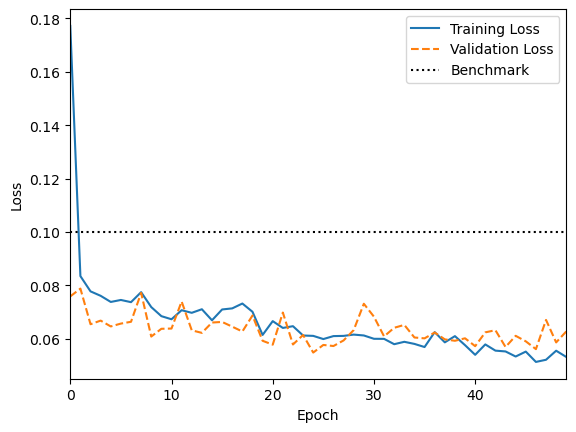

variance of returns for old data:  0.00430218643497445
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 2.4734e+02,  2.5361e+06,  1.3023e+11,  1.7475e-02, -1.0338e-03,
         -1.5223e-03, -1.0379e-05,  2.4274e+02,  2.4300e+02,  5.5862e+01,
          2.7012e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(241.1574)
windows last2 price:  tensor(243.8910)
windows last3 price:  tensor(238.6722)
period from idx:  0  to idx  10
prediction at 10:  tensor(246.2506)
last price from test data:  241.15737915039065
real price 10 steps forward:  tensor(264.1200)
kelly weight:  {tensor(0.3220)}
 
lw mean tensor([[ 2.4903e+02,  1.9755e+06,  1.3112e+11,  1.7751e-02, -2.1877e-04,
         -4.4376e-04,  1.7530e-06,  2.4819e+02,  2.4679e+02,  5.3080e+01,
          2.9767e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(264.1200)
windows last2 price:  tensor(25

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


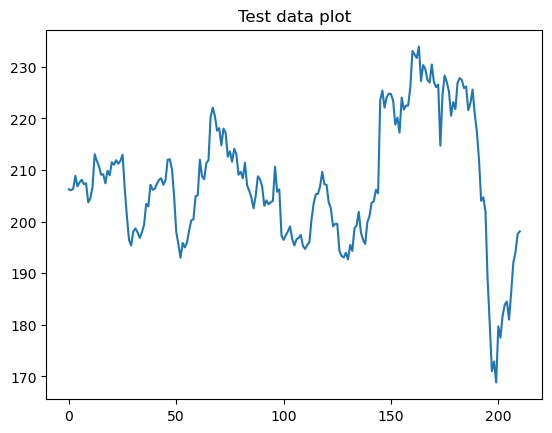

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.09454212e+01  6.67306000e+06  2.62737273e+10  1.43827794e-02
 -3.44828405e-02 -3.50914046e-02 -4.95959087e-04  2.33105825e+01
  2.28798623e+01  2.62368658e+01  2.62327041e-02]
[8.00968163e+01 1.17357520e+07 1.00472647e+11 3.70227664e-02
 9.38113707e-04 7.24361512e-04 3.63250079e-05 7.98008479e+01
 7.97954365e+01 5.21433875e+01 1.88343730e-02]
[5.59559190e+01 1.45533859e+07 7.01905461e+10 1.03834912e-02
 2.06626710e-02 2.06637764e-02 8.16611664e-04 5.56288714e+01
 5.55827152e+01 1.11958175e+01 8.25050530e-03]
[-1.05710703 -0.34787039 -1.05710703 -2.18038293 -1.71424857 -1.73326334
 -0.65182034 -1.01548466 -1.02397974 -2.31394642  0.89671247]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 3.506602619876381
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

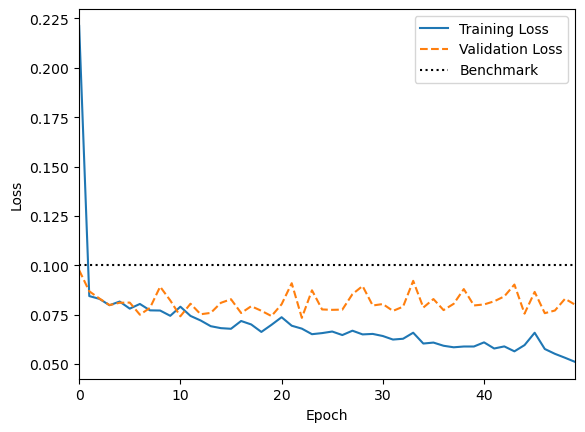

variance of returns for old data:  0.0034194212428463183
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 2.1681e+02,  2.1542e+06,  2.7196e+11,  3.6498e-02, -5.7099e-03,
         -5.8052e-03, -2.0769e-04,  2.2360e+02,  2.2208e+02,  4.1000e+01,
          1.4561e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(205.9773)
windows last2 price:  tensor(211.1267)
windows last3 price:  tensor(210.0580)
period from idx:  0  to idx  10
prediction at 10:  tensor(216.8506)
last price from test data:  205.97727966308597
real price 10 steps forward:  tensor(204.5199)
kelly weight:  {tensor(0.9027)}
 
lw mean tensor([[ 2.0904e+02,  2.1438e+06,  2.6221e+11,  3.5494e-02, -2.5889e-03,
         -2.6627e-03, -9.0609e-05,  2.1629e+02,  2.1503e+02,  3.6490e+01,
          1.3149e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(204.5199)
windows last2 price:  tensor(

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


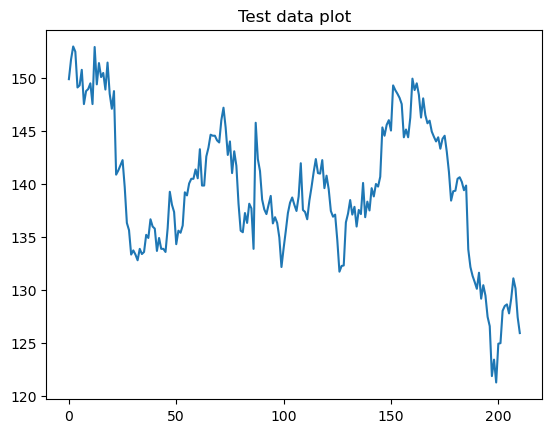

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 5.52285314e-01  3.10878280e+07  3.53173186e+08  1.93334275e-04
 -1.11606881e-02 -1.12234359e-02 -2.15774354e-06  6.08324277e-01
  5.96864715e-01  2.75111428e+01  2.82628697e-02]
[3.90201805e+01 1.53608995e+07 2.49524677e+10 6.28671697e-03
 6.24644341e-04 4.59351406e-04 6.76414519e-06 3.87660332e+01
 3.87677428e+01 5.39921234e+01 1.65638987e-02]
[5.04007185e+01 1.81478778e+07 3.22300483e+10 6.00314556e-03
 1.84272749e-02 1.80626347e-02 1.49286803e-04 5.01412591e+01
 5.01266071e+01 1.24199088e+01 8.83485667e-03]
[-0.76324101  0.86659877 -0.76324101 -1.01503164 -0.63955916 -0.64679309
 -0.05976341 -0.7610042  -0.76148936 -2.13213971  1.32418345]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.5935115249082206
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

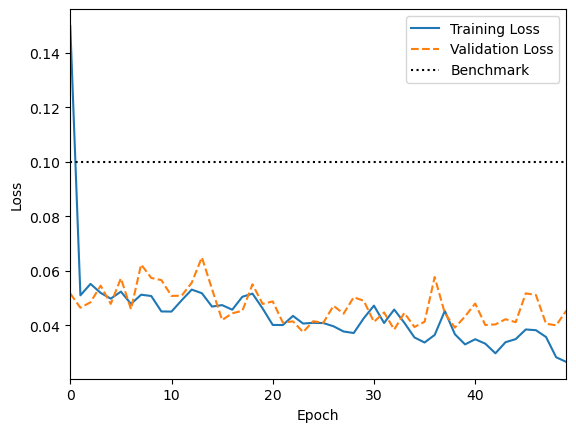

variance of returns for old data:  0.003308464852276376
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.5311e+02,  1.4167e+06,  9.7910e+10,  1.3141e-02, -1.5299e-03,
         -1.5768e-03, -1.9652e-05,  1.5743e+02,  1.5607e+02,  4.2261e+01,
          1.2381e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(150.9236)
windows last2 price:  tensor(152.7308)
windows last3 price:  tensor(152.7796)
period from idx:  0  to idx  10
prediction at 10:  tensor(153.1172)
last price from test data:  150.92361450195312
real price 10 steps forward:  tensor(149.4583)
kelly weight:  {tensor(0.2527)}
 
lw mean tensor([[ 1.5074e+02,  1.2296e+06,  9.6396e+10,  1.3049e-02, -5.7083e-04,
         -6.2967e-04, -6.8775e-06,  1.5339e+02,  1.5315e+02,  4.1942e+01,
          1.1006e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(149.4583)
windows last2 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


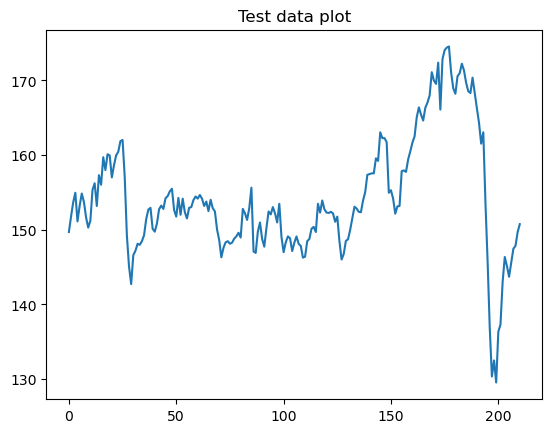

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 1.40866518e+01  2.74833100e+06  2.75132026e+10  1.50612937e-02
 -2.50000215e-02 -2.53178300e-02 -3.76532666e-04  1.50934836e+01
  1.50184601e+01  2.43184247e+01  1.42116058e-02]
[4.77137479e+01 6.25551476e+06 9.31916281e+10 3.60090433e-02
 7.35149965e-04 4.94912191e-04 2.94225971e-05 4.75073805e+01
 4.75069975e+01 5.29571428e+01 1.86182153e-02]
[2.93662937e+01 4.33140776e+06 5.73564819e+10 8.85197042e-03
 2.19227568e-02 2.19148099e-02 7.37881516e-04 2.90705020e+01
 2.90535912e+01 1.13243684e+01 1.23453914e-02]
[-1.1450916  -0.8097099  -1.1450916  -2.36645047 -1.17390216 -1.17786749
 -0.55016321 -1.11500988 -1.11822794 -2.52894618 -0.35694368]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.8186955203837398
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

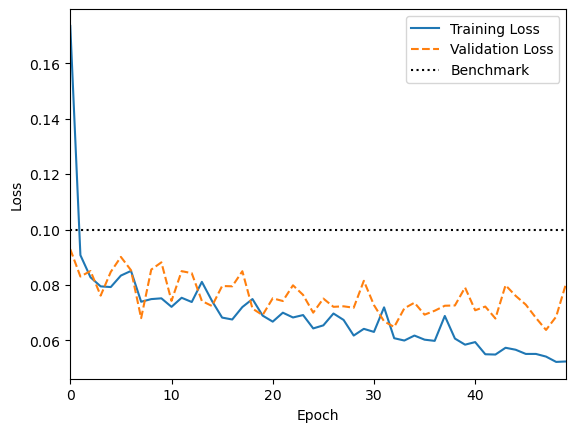

variance of returns for old data:  0.003937104912139465
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[1.4813e+02, 3.2873e+06, 2.8931e+11, 3.8831e-02, 1.5298e-03, 1.4707e-03,
         5.9527e-05, 1.4752e+02, 1.4728e+02, 5.3108e+01, 1.2779e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(149.0575)
windows last2 price:  tensor(150.8740)
windows last3 price:  tensor(150.3340)
period from idx:  0  to idx  10
prediction at 10:  tensor(148.0473)
last price from test data:  149.05746459960938
real price 10 steps forward:  tensor(151.2177)
kelly weight:  {tensor(-0.1080)}
 
lw mean tensor([[1.5120e+02, 3.1052e+06, 2.9532e+11, 3.9980e-02, 8.0609e-04, 7.3690e-04,
         3.3340e-05, 1.4894e+02, 1.4923e+02, 5.6565e+01, 1.1744e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(151.2177)
windows last2 price:  tensor(150.2849)
windows last3 price:  tensor(1

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


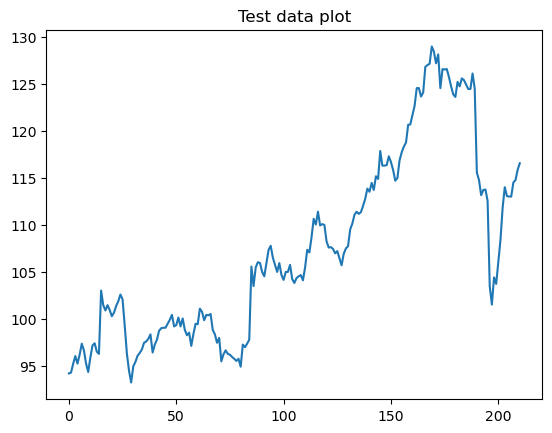

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 1.21157541e+01  4.13292800e+06  2.35624767e+10  1.28985850e-02
 -4.83058221e-03 -4.84228719e-03 -6.23076752e-05  1.24951056e+01
  1.23746467e+01  4.12187009e+01  2.13615980e-02]
[ 4.75616240e+01  5.71799634e+06  9.24968967e+10  3.67226480e-02
  1.08249987e-04 -4.24332412e-05  4.26841614e-06  4.74483738e+01
  4.74444306e+01  5.20192147e+01  1.53278052e-02]
[2.53432149e+01 3.91164788e+06 4.92869783e+10 9.47064135e-03
 1.73377349e-02 1.73743607e-02 6.30411584e-04 2.52818226e+01
 2.52606815e+01 1.10833116e+01 8.22199527e-03]
[-1.39863352 -0.40521754 -1.39863352 -2.51557018 -0.28486029 -0.27626075
 -0.10560734 -1.38254543 -1.38831503 -0.97448436  0.73385992]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 1.6561146628571544
Normalized Benchmark: 0.1


INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

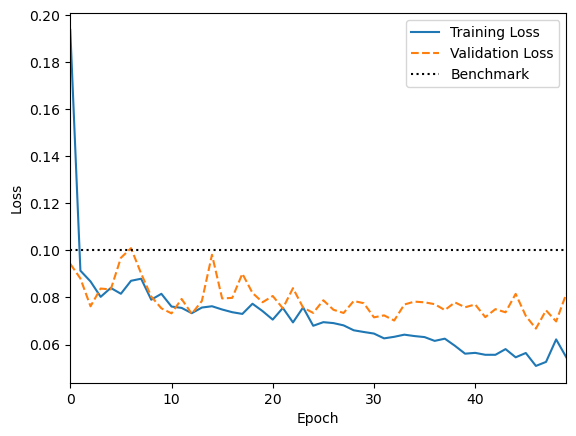

variance of returns for old data:  0.0024018254318760868
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[9.3563e+01, 5.5455e+06, 1.8196e+11, 2.4422e-02, 8.7432e-04, 8.1221e-04,
         2.1818e-05, 9.2899e+01, 9.3562e+01, 4.7840e+01, 1.0905e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(93.6580)
windows last2 price:  tensor(94.9313)
windows last3 price:  tensor(94.1295)
period from idx:  0  to idx  10
prediction at 10:  tensor(93.5136)
last price from test data:  93.657958984375
real price 10 steps forward:  tensor(95.8744)
kelly weight:  {tensor(-0.0315)}
 
lw mean tensor([[9.4869e+01, 4.8594e+06, 1.8450e+11, 2.4977e-02, 1.2818e-03, 1.2216e-03,
         3.2696e-05, 9.3815e+01, 9.4117e+01, 5.2642e+01, 1.0939e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(95.8744)
windows last2 price:  tensor(94.3182)
windows last3 price:  tensor(95.2142)
p

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


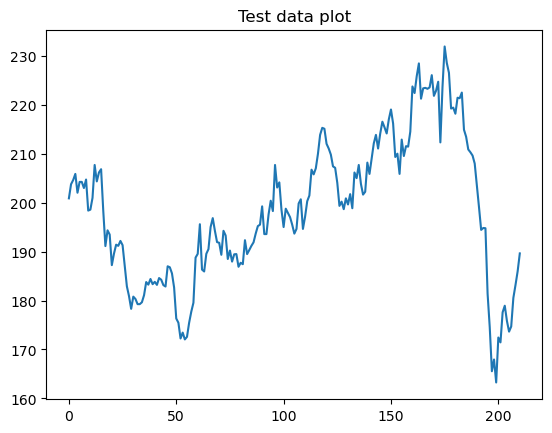

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.17024612e+01  6.15515200e+06  9.25436352e+09  5.06602918e-03
 -1.22249355e-02 -1.23002746e-02 -6.19318798e-05  2.35423344e+01
  2.31997035e+01  3.48655619e+01  2.78043304e-02]
[9.37715042e+01 4.76139453e+06 3.99860448e+10 1.57744897e-02
 5.53232061e-04 3.45592475e-04 1.08138477e-05 9.34742001e+01
 9.34729715e+01 5.19702212e+01 1.89066651e-02]
[5.20390761e+01 5.49302488e+06 2.21905028e+10 5.17947595e-03
 2.03890567e-02 2.03713181e-02 3.39690460e-04 5.17523620e+01
 5.17045363e+01 1.12660989e+01 7.60847889e-03]
[-1.38490243  0.25373223 -1.38490243 -2.06747953 -0.62671695 -0.62076823
 -0.21415299 -1.35127872 -1.35913158 -1.51824153  1.16944076]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 4.086537555640331
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

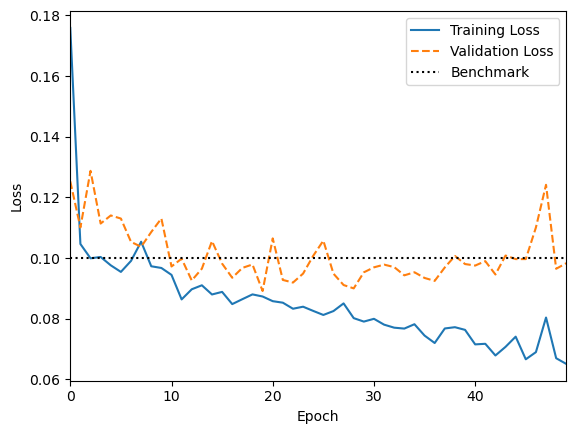

variance of returns for old data:  0.003409202130093379
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 2.1226e+02,  1.5066e+06,  9.0513e+10,  1.2147e-02, -5.0649e-03,
         -5.1798e-03, -6.0363e-05,  2.2060e+02,  2.1838e+02,  3.9153e+01,
          1.1968e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(201.7746)
windows last2 price:  tensor(204.8522)
windows last3 price:  tensor(206.0063)
period from idx:  0  to idx  10
prediction at 10:  tensor(212.0239)
last price from test data:  201.7745819091797
real price 10 steps forward:  tensor(198.6008)
kelly weight:  {tensor(0.8700)}
 
lw mean tensor([[ 2.0413e+02,  1.2933e+06,  8.7043e+10,  1.1782e-02, -4.1593e-03,
         -4.2968e-03, -4.8353e-05,  2.1194e+02,  2.1094e+02,  3.6022e+01,
          1.4333e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(198.6008)
windows last2 price:  tensor(19

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


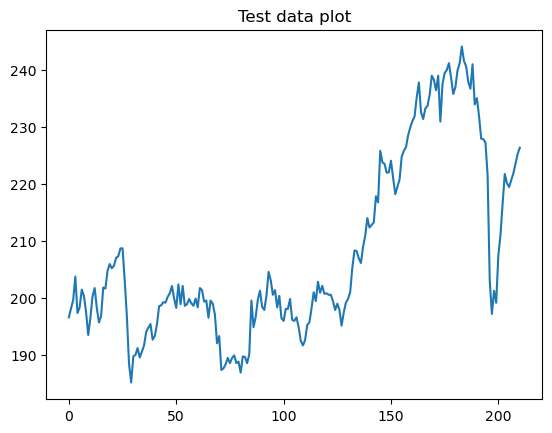

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 2.53812160e+01  1.73165900e+06  2.85297571e+10  1.56177766e-02
 -3.68850819e-02 -3.75825408e-02 -5.76062968e-04  2.71038941e+01
  2.68580950e+01  2.58662916e+01  1.72791768e-02]
[7.55564046e+01 3.70696329e+06 8.49291802e+10 3.30647920e-02
 5.47133301e-04 3.37632833e-04 2.00336884e-05 7.52778166e+01
 7.52765573e+01 5.29743320e+01 1.75901557e-02]
[4.38492942e+01 3.55874962e+06 4.92888012e+10 9.21431706e-03
 2.04341431e-02 2.04891544e-02 5.59819890e-04 4.35195532e+01
 4.34885631e+01 1.16695556e+01 1.17296153e-02]
[-1.14426445 -0.55505571 -1.14426445 -1.8934681  -1.83184658 -1.85074372
 -1.06480078 -1.10694892 -1.11336082 -2.32297109 -0.02651228]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 2.865833637555646
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

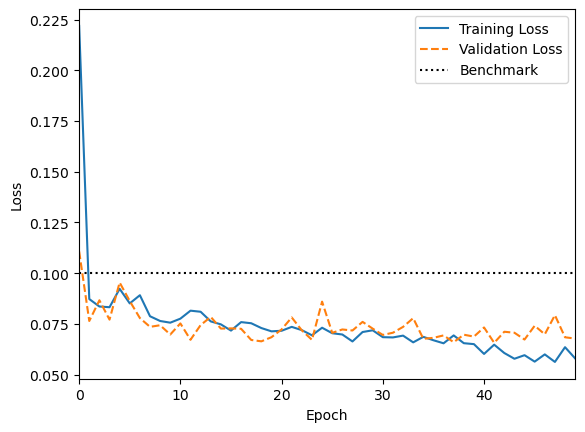

variance of returns for old data:  0.003988040586865326
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 1.9741e+02,  2.4155e+06,  2.2190e+11,  2.9782e-02,  8.8266e-05,
         -1.8626e-10,  4.2116e-06,  1.9822e+02,  1.9782e+02,  4.9650e+01,
          1.3514e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(196.8384)
windows last2 price:  tensor(199.4922)
windows last3 price:  tensor(195.7402)
period from idx:  0  to idx  10
prediction at 10:  tensor(197.1198)
last price from test data:  196.83837890625
real price 10 steps forward:  tensor(196.3808)
kelly weight:  {tensor(0.0226)}
 
lw mean tensor([[ 1.9759e+02,  2.3265e+06,  2.2210e+11,  3.0066e-02, -6.0462e-05,
         -1.6266e-04, -1.5331e-07,  1.9782e+02,  1.9777e+02,  4.9898e+01,
          1.3817e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(196.3808)
windows last2 price:  tensor(193.

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


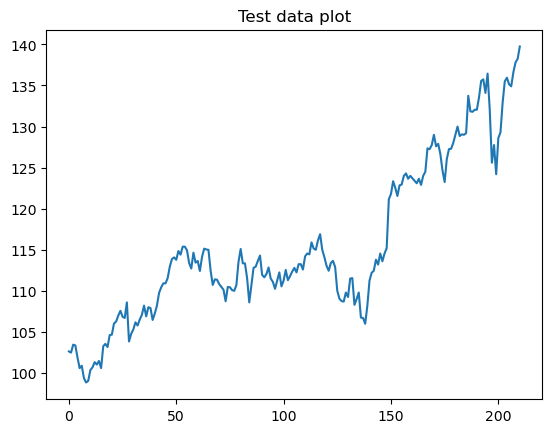

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 4.89801369e+01  1.16962100e+06  3.34324716e+10  1.83016234e-02
 -5.16667485e-02 -5.30493074e-02 -9.45585376e-04  4.81021118e+01
  4.92007052e+01  4.97850548e+01  3.30417673e-02]
[5.07407973e+01 2.52135546e+06 3.46342491e+10 1.46020131e-02
 6.16368367e-04 3.98128192e-04 1.15093381e-05 5.06443702e+01
 5.06496844e+01 5.16038273e+01 1.83592658e-02]
[2.30956997e+01 1.66726762e+06 1.57644787e+10 4.13453902e-03
 2.06719287e-02 2.10102145e-02 3.17137746e-04 2.29620501e+01
 2.29381174e+01 1.22540341e+01 9.67886213e-03]
[-0.07623326 -0.81074834 -0.07623326  0.89480601 -2.52918427 -2.54387863
 -3.01791485 -0.11071565 -0.06316906 -0.14842235  1.51696565]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 2.0943818761212794
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

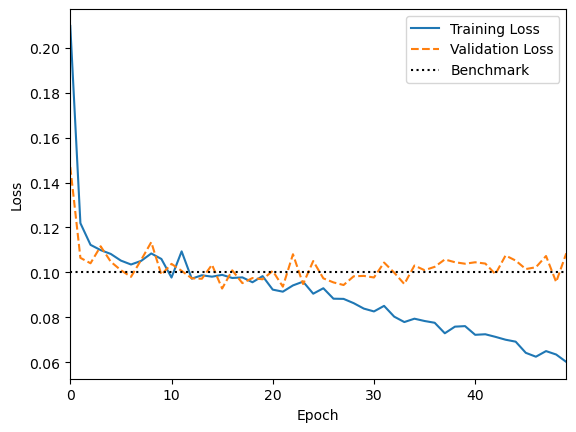

variance of returns for old data:  0.004108959167956797
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[1.0059e+02, 2.1232e+06, 6.8660e+10, 9.2158e-03, 2.2817e-03, 2.2495e-03,
         2.1194e-05, 9.9062e+01, 9.8784e+01, 6.5218e+01, 8.1398e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(102.4857)
windows last2 price:  tensor(103.4553)
windows last3 price:  tensor(103.0190)
period from idx:  0  to idx  10
prediction at 10:  tensor(101.2488)
last price from test data:  102.48567199707033
real price 10 steps forward:  tensor(100.3526)
kelly weight:  {tensor(-0.1883)}
 
lw mean tensor([[ 1.0133e+02,  1.9025e+06,  6.9166e+10,  9.3631e-03, -5.4982e-05,
         -9.5057e-05, -3.2381e-07,  1.0062e+02,  1.0047e+02,  5.9430e+01,
          7.8180e-03]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(100.3526)
windows last2 price:  tensor(99.0436)
windows las

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


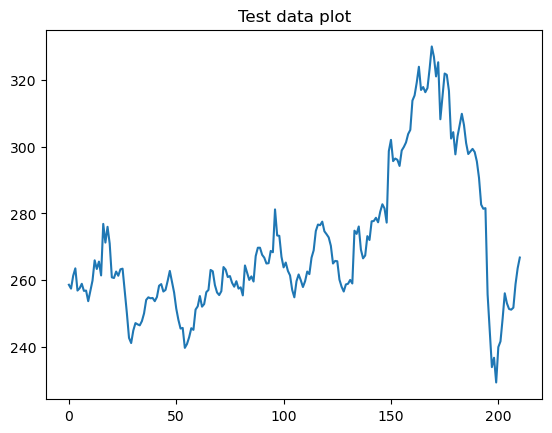

INFO: 
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection     | 0      | train
2 | val_metrics   | MetricCollection     | 0      | train
3 | test_metrics  | MetricCollection     | 0      | train
4 | model         | CrossAttentionLSTMV1 | 617 K  | train
5 | optimizer     | Adam                 | 0      | train
---------------------------------------------------------------
617 K     Trainable params
0         Non-trainable params
617 K     Total params
2.468     Total estimated model params size (MB)
13        Modules in train mode
1         Modules in eval mode
INFO:lightning.pytorch.callbacks.model_summary:
  | Name          | Type                 | Params | Mode 
---------------------------------------------------------------
0 | loss          | L1Loss               | 0      | eval 
1 | train_metrics | MetricCollection  

in sequences shape:  (1234, 20, 11)
targets shape:  (1234, 1)
[ 1.63902645e+01  2.72569000e+07  2.60359347e+10  1.42526068e-02
 -9.34555413e-03 -9.38949782e-03 -1.33198508e-04  1.70300261e+01
  1.69249449e+01  3.33200238e+01  1.43622256e-02]
[7.31426535e+01 1.20255126e+07 1.16187103e+11 4.10584204e-02
 4.38964586e-04 2.25974226e-04 2.59204801e-05 7.27584700e+01
 7.27534037e+01 5.25263962e+01 1.84392020e-02]
[5.74726390e+01 1.44605699e+07 9.12952853e+10 1.27637221e-02
 2.06027656e-02 2.06586234e-02 8.86640597e-04 5.69122986e+01
 5.68660874e+01 1.21765506e+01 8.38604531e-03]
[-0.98746795  1.05330478 -0.98746795 -2.10015648 -0.47491288 -0.46544592
 -0.17946278 -0.97919861 -0.98175312 -1.57732457 -0.48616198]
in sequences norm shape:  (1234, 20, 11)
targets norm shape:  (1234, 1)
train loader length:  31
val loader length:  8
Benchmark Celsius: 3.1878778267153325
Normalized Benchmark: 0.1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (31) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

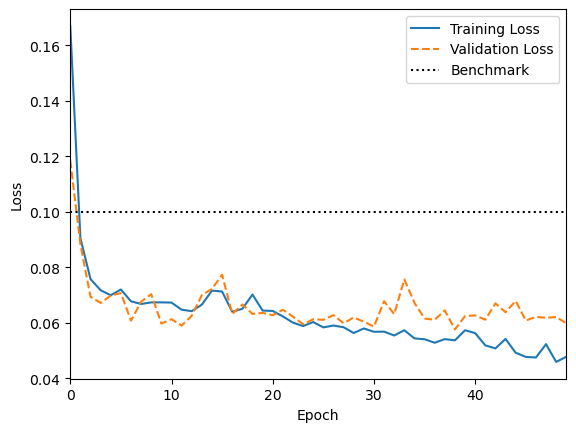

variance of returns for old data:  0.0038268847946617388
start window shape:  torch.Size([20, 11])
test data shape torch.Size([211, 11])
lw mean tensor([[ 2.6479e+02,  3.6739e+06,  4.2062e+11,  5.6450e-02, -3.2647e-03,
         -3.3761e-03, -1.7895e-04,  2.7083e+02,  2.6993e+02,  4.2626e+01,
          1.2590e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(258.0771)
windows last2 price:  tensor(261.5477)
windows last3 price:  tensor(258.2699)
period from idx:  0  to idx  10
prediction at 10:  tensor(264.7905)
last price from test data:  258.0771179199219
real price 10 steps forward:  tensor(256.8238)
kelly weight:  {tensor(0.4205)}
 
lw mean tensor([[ 2.5813e+02,  2.7164e+06,  4.1003e+11,  5.5505e-02, -1.1568e-03,
         -1.2256e-03, -6.2055e-05,  2.6458e+02,  2.6376e+02,  4.0732e+01,
          1.4208e-02]])
ret shape torch.Size([])
x_in shape:  torch.Size([1, 20, 11])
windows last price:  tensor(256.8238)
windows last2 price:  tensor(2

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:89: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_260508\769953786.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[idx_start+1:idx_end,:], dtype = torch.float32)


In [88]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from single_asset_models.SimpleGRU import SimpleGRU
from single_asset_models.SimpleLSTM import SimpleLSTM
from train.train_functions import plot_training, test_model_output
from model_inference.inference_functions import test_model_output_percentage_diff
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
MAPE = []
#tickers = ['TEL2-B.ST']
epochs = 50
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark, train_mean, train_std = generate_loaders_and_benchmark_new_norm(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=120, num_hidden_layers=5, out_dim=1, dropout=0.1, num_heads=24)
    #simple_lstm = SimpleLSTM(input_size=n_features, hidden_size=120, num_hidden_layers=3, output_size=1, dropout=0.1)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_lstm_v1
    #chosen_model = simple_lstm
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions_new_norm(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)
    print('\n \n \n TEST \n \n')
    test_loader = generate_test_data_loader(data_values[-num_test_points:])
    mape_ticker = test_model_output_percentage_diff_new_norm(chosen_model_reg, test_loader, train_mean, train_std, target_idx)
    MAPE.append(mape_ticker)

all mean abs percent errors per ticker [3.7203407287597656, 5.345650672912598, 5.321872234344482, 5.730513095855713, 9.222436904907227, 5.509756565093994, 7.533354759216309, 9.25876522064209, 4.927792072296143, 3.3135874271392822, 7.5369038581848145, 4.084550857543945, 6.959136009216309, 8.197249412536621, 5.733086109161377, 4.754560947418213, 4.1808390617370605, 4.584381103515625, 5.752279758453369, 4.195815086364746, 3.6126770973205566, 6.157203674316406]
all mean 5.710579666224393
(22, 210)
(210,)


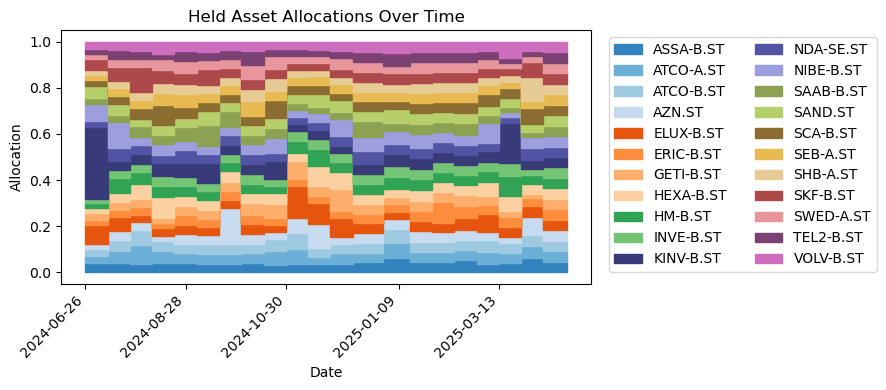

In [89]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005
print('all mean abs percent errors per ticker',MAPE)
print('all mean', np.mean(MAPE))

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

test_indices = df.index[-(num_test_points)*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]
#print(all_weights.shape)

all_weights = np.array(all_weights)

np.save('saved_weights\\cross_lstm_200testpoints_10horizon_120hidden_5l_24head_new_norm_20ws_5step_17_04_23.npy', all_weights)

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::45], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

210
ret assa 11-12 jul -0.0016978179597979001
(210,)
Portfoliot final return:  0.9943922308941796
(210,)
Index final return 0.950307367604208


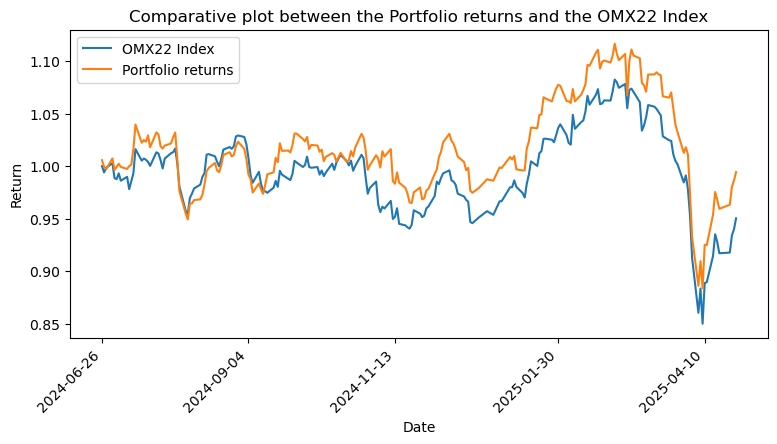

In [90]:
from allocation_functions.allocation_functions import calculate_asset_returns_cont, calculate_portfolio_returns, calculate_cumulative_portfolio_returns
import matplotlib.pyplot as plt

print(len(test_indices))

returns = calculate_asset_returns_cont(df, tickers, num_of_test_points=num_test_points)
print('ret assa 11-12 jul', returns[0,0] )

#print(alloc.shape)
#print(returns)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
#print(portfolio_returns)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
print(portfolio_returns_with_tradingcost.shape)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:-1].values

#index_diffs = np.diff(index_test_values, axis=0)
#index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
index_diffs = index_test_values / index_test_values[0]
print(index_diffs.shape)
#print(index_diffs)
#cum_prod_index = 1 * np.cumprod(1 + index_diffs)
#cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
cum_prod_index = index_diffs
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::50], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



torch.Size([32, 20, 20])
Randomly selected samples: [18, 20, 2, 13]


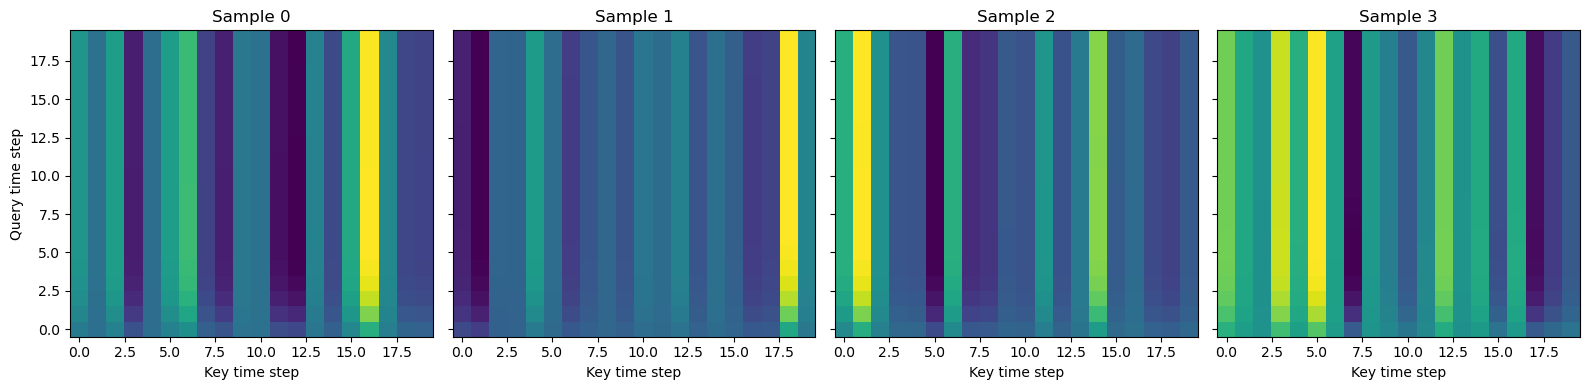

TypeError: Invalid shape (1, 20, 20) for image data

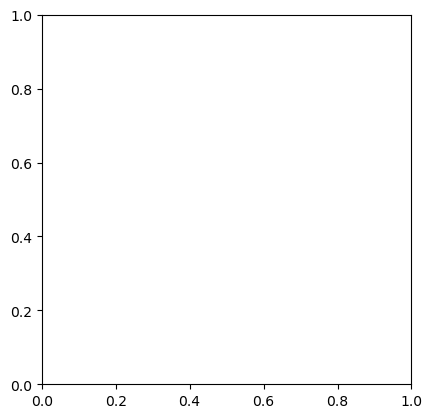

In [91]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()